<a href="https://colab.research.google.com/github/SahilKumar001u/Retail-Seasonal-Demand-Forecasting-System/blob/main/RetailForecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data → Cleaning → Time Series → Stationarity → ARIMA/SARIMA → Forecast

STEP 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STEP 2: Upload Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

df=pd.read_csv('perrin-freres-monthly-champagne-.csv')
df.head()

Saving perrin-freres-monthly-champagne-.csv to perrin-freres-monthly-champagne-.csv


,Month,Perrin Freres monthly champagne sales millions ?64-?72
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0


STEP 3: Basic EDA

In [ ]:
df.tail()

,Month,Perrin Freres monthly champagne sales millions ?64-?72
102,1972-07,4298.0
103,1972-08,1413.0
104,1972-09,5877.0
105,NaN,NaN
106,Perrin Freres monthly champagne sales millions...,NaN


In [ ]:
df.columns=["Month","Sales"]
df.head()

,Month,Sales
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0


In [ ]:
df.drop(106,axis=0,inplace=True)

In [ ]:
df.drop(105,axis=0,inplace=True)
df.tail()

,Month,Sales
100,1972-05,4618.0
101,1972-06,5312.0
102,1972-07,4298.0
103,1972-08,1413.0
104,1972-09,5877.0


STEP 4: Data Cleaning

In [ ]:
df['Month']=pd.to_datetime(df['Month'])


In [ ]:
df.set_index('Month',inplace=True)


In [ ]:
df.head()

,Sales
Month,
1964-01,2815.0
1964-02,2672.0
1964-03,2755.0
1964-04,2721.0
1964-05,2946.0


In [ ]:
df.describe()

STEP 5: Time Series Preparation

In [ ]:
df.head()

,Sales
Month,
1964-01-01,2815.0
1964-02-01,2672.0
1964-03-01,2755.0
1964-04-01,2721.0
1964-05-01,2946.0


<Axes: xlabel='Month'>

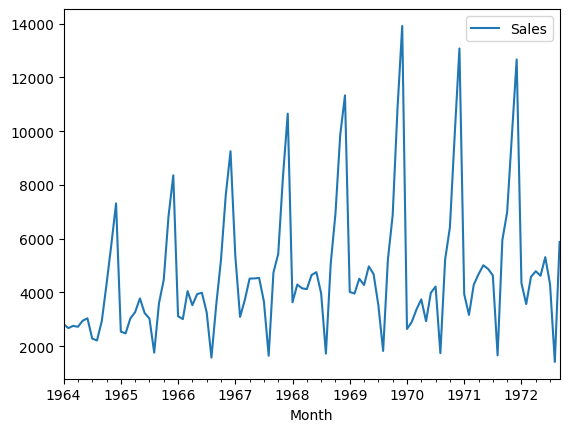

In [ ]:
df.plot()

STEP 6: ADF Test (Stationarity)

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adfuller_test(sales):
    result = adfuller(sales)

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] <= 0.05:
        print("Data is stationary")
    else:
        print("Data is non-stationary")

In [ ]:
adfuller_test(df['Sales'])

ADF Statistic: -1.8335930563276215
p-value: 0.36391577166024586
Data is non-stationary


STEP 7: First Differencing

ADF Statistic: -7.189896448050999
p-value: 2.519620447387081e-10
Data is stationary


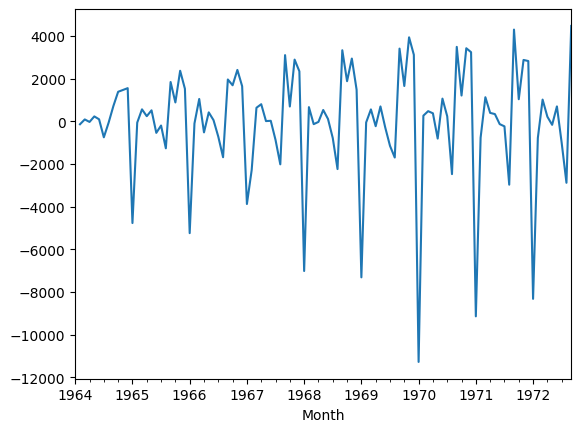

In [ ]:
df['Sales First Difference'] = df['Sales'] - df['Sales'].shift(1)
df['Sales'].shift(1)
df['Sales First Difference'].plot()
adfuller_test(df['Sales First Difference'].dropna())



STEP 8: Seasonal Differencing

ADF Statistic: -7.626619157213166
p-value: 2.0605796968136632e-11
Data is stationary


<Axes: xlabel='Month'>

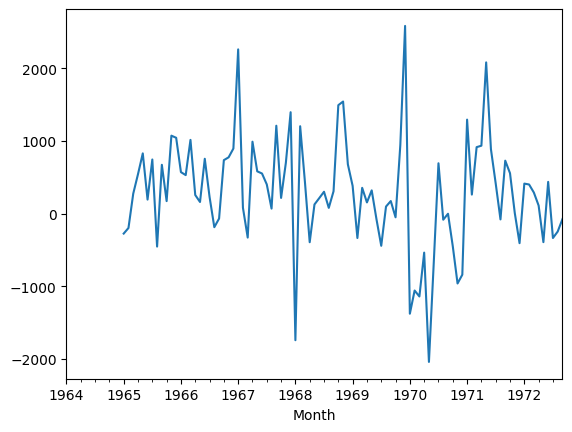

In [ ]:
df['Seasonal First Difference']=df['Sales']-df['Sales'].shift(12)
df.head(14)
adfuller_test(df['Seasonal First Difference'].dropna())
df['Seasonal First Difference'].plot()

STEP 9: ACF & PACF

In [ ]:
import statsmodels.api as sm

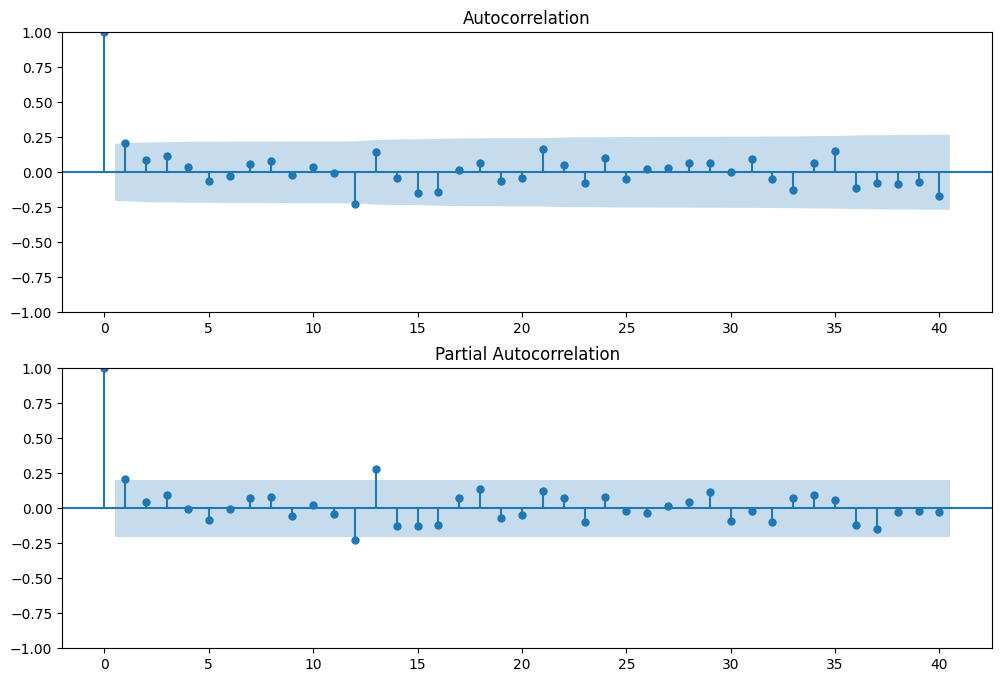

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df['Seasonal First Difference'].iloc[13:],lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['Seasonal First Difference'].iloc[13:],lags=40,ax=ax2)

STEP 10: ARIMA Model

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
arima_model = ARIMA(df['Sales'], order=(1,1,1))
arima_result = arima_model.fit()
print(arima_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  105
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -952.814
Date:                Fri, 27 Mar 2026   AIC                           1911.627
Time:                        15:38:04   BIC                           1919.560
Sample:                    01-01-1964   HQIC                          1914.841
                         - 09-01-1972                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4545      0.114      4.000      0.000       0.232       0.677
ma.L1         -0.9666      0.056    -17.319      0.000      -1.076      -0.857
sigma2      5.226e+06   6.17e+05      8.473      0.0

STEP 11: ARIMA Forecast

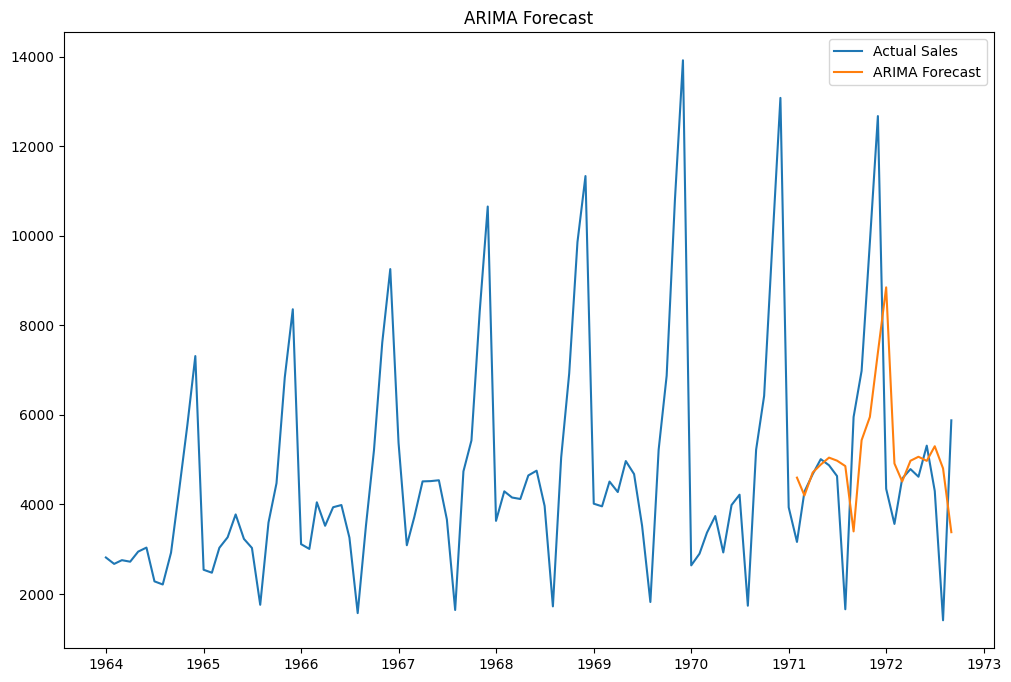

In [ ]:
arima_forecast = arima_result.predict(
    start=len(df['Sales'])-20,
    end=len(df['Sales'])-1
)
plt.figure(figsize=(12,8))
plt.plot(df['Sales'], label='Actual Sales')
plt.plot(arima_forecast, label='ARIMA Forecast')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

STEP 12: SARIMA Model and SARIMA Forecast

In [ ]:
sarima_model = sm.tsa.statespace.SARIMAX(
   df['Sales'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()
print(sarima_result.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                  105
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -738.402
Date:                            Fri, 27 Mar 2026   AIC                           1486.804
Time:                                    15:38:19   BIC                           1499.413
Sample:                                01-01-1964   HQIC                          1491.893
                                     - 09-01-1972                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2790      0.081      3.433      0.001       0.120       0.438
ma.L1         -0.9494      0.043   

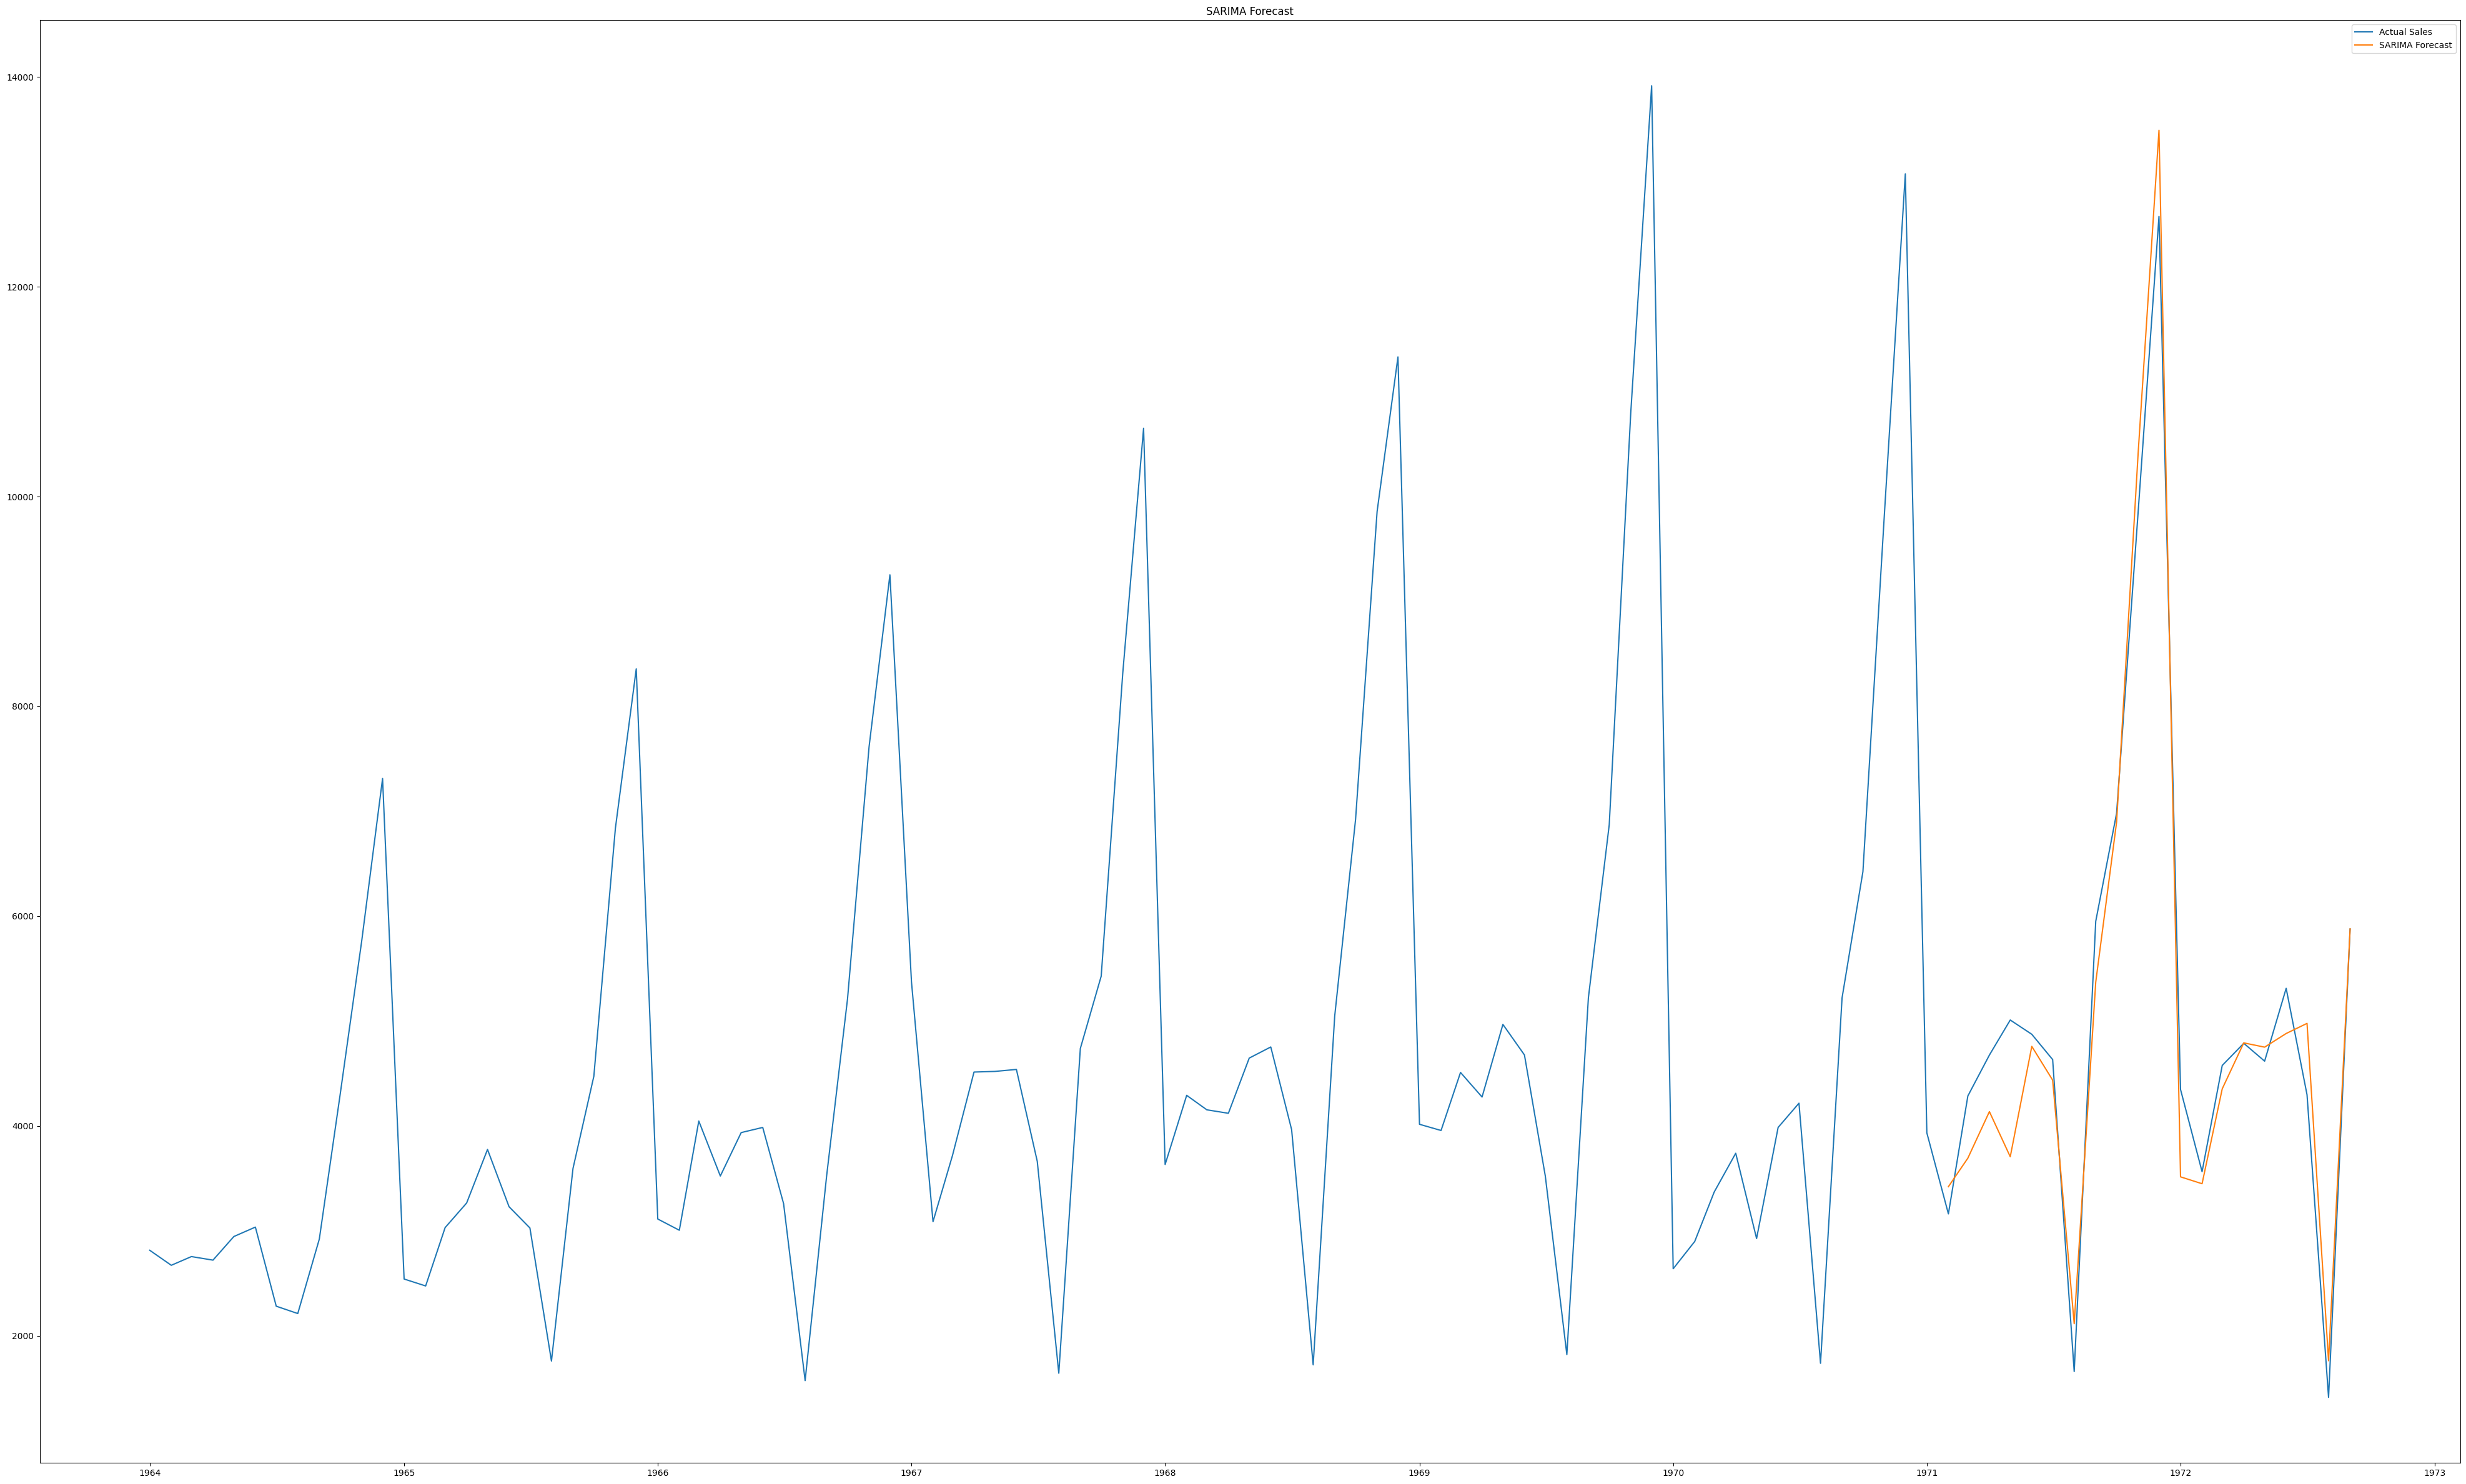

In [ ]:
sarima_forecast = sarima_result.predict(
    start=len(df['Sales'])-20,
    end=len(df['Sales'])-1
)

plt.figure(figsize=(50,30))
plt.plot(df['Sales'], label='Actual Sales')
plt.plot(sarima_forecast, label='SARIMA Forecast')
plt.legend()
plt.title("SARIMA Forecast")
plt.show()